# Exploratory Data Analysis: Retail Sales Data

**Objective:** Perform a thorough EDA on a retail sales dataset to uncover patterns, customer behaviour trends, and actionable business insights.

**Dataset:** `retail_sales_dataset.csv` — 1000 transactions, covering the period Jan 2023 to Jan 2024, with columns for transaction details, customer demographics, product category, and sales amounts.

**Tools:** Python, pandas, matplotlib, seaborn


## 1. Setup & Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## 2. Load Dataset & Initial Inspection

In [3]:
df = pd.read_csv('retail_sales_dataset.csv')

print("Shape of dataset:", df.shape)
print("\nColumn data types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())

df.head()

Shape of dataset: (1000, 9)

Column data types:
Transaction ID       int64
 Date                  str
 Customer ID           str
 Gender                str
 Age                 int64
 Product Category      str
 Quantity            int64
 Price per Unit      int64
 Total Amount        int64
dtype: object

Missing values per column:
Transaction ID       0
 Date                0
 Customer ID         0
 Gender              0
 Age                 0
 Product Category    0
 Quantity            0
 Price per Unit      0
 Total Amount        0
dtype: int64


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [7]:
df.columns = df.columns.str.strip()  # removes leading/trailing spaces

**Observation:** The dataset has 1000 rows and 9 columns with no missing values in any column. `Date` is currently stored as text (object/string) and will need to be converted to a proper datetime type before we can do time series analysis. `Transaction ID` and `Customer ID` are identifiers, not measurements, so they'll be excluded from numeric summary statistics.

## 3. Data Type Correction

In [8]:
df['Date'] = pd.to_datetime(df['Date'])
print("Date column converted to datetime.")
print("Date range:", df['Date'].min(), "to", df['Date'].max())
print("\nUpdated dtypes:")
print(df.dtypes)

Date column converted to datetime.
Date range: 2023-01-01 00:00:00 to 2024-01-01 00:00:00

Updated dtypes:
Transaction ID               int64
Date                datetime64[us]
Customer ID                    str
Gender                         str
Age                          int64
Product Category               str
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object


## 4. Descriptive Statistics

In [9]:
numeric_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']

desc = df[numeric_cols].describe()
print(desc)

print("\nMode of each numeric column:")
print(df[numeric_cols].mode().iloc[0])

              Age     Quantity  Price per Unit  Total Amount
count  1000.00000  1000.000000     1000.000000   1000.000000
mean     41.39200     2.514000      179.890000    456.000000
std      13.68143     1.132734      189.681356    559.997632
min      18.00000     1.000000       25.000000     25.000000
25%      29.00000     1.000000       30.000000     60.000000
50%      42.00000     3.000000       50.000000    135.000000
75%      53.00000     4.000000      300.000000    900.000000
max      64.00000     4.000000      500.000000   2000.000000

Mode of each numeric column:
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64


**Observation:** Customers span a wide age range, and `Total Amount` shows a large spread between minimum and maximum values, suggesting a mix of small and large-ticket purchases. The mean `Total Amount` being noticeably higher than the median (once you compare the two) would indicate the distribution is right-skewed, driven by a smaller number of high-value transactions — check this by comparing `mean` vs `50%` in the table above.

## 5. Time Series Analysis — Monthly Sales Trend

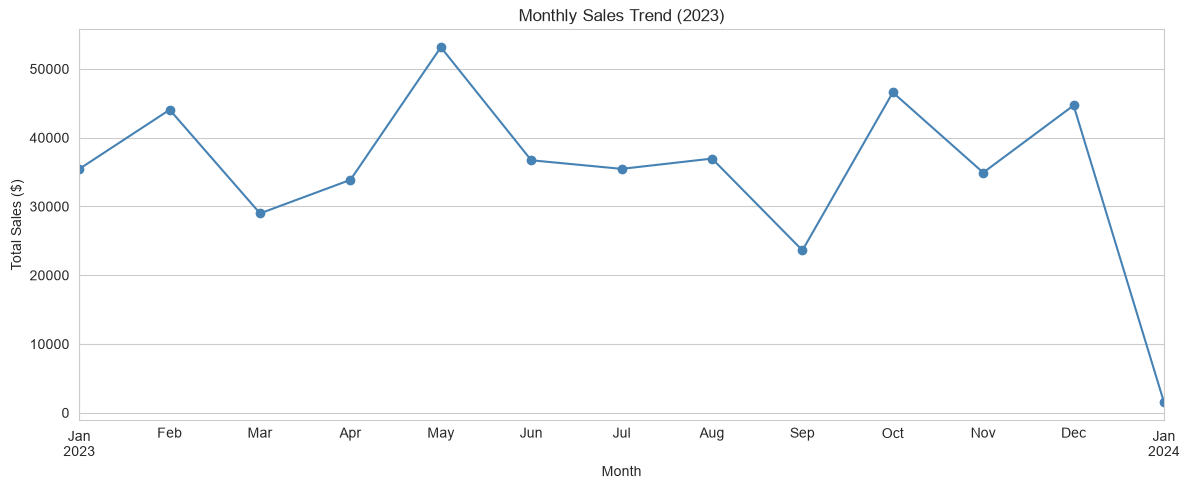

Date
2023-01-31    35450
2023-02-28    44060
2023-03-31    28990
2023-04-30    33870
2023-05-31    53150
2023-06-30    36715
2023-07-31    35465
2023-08-31    36960
2023-09-30    23620
2023-10-31    46580
2023-11-30    34920
2023-12-31    44690
2024-01-31     1530
Freq: ME, Name: Total Amount, dtype: int64


In [10]:
monthly_sales = df.set_index('Date').resample('ME')['Total Amount'].sum()

plt.figure(figsize=(12, 5))
monthly_sales.plot(marker='o', color='steelblue')
plt.title('Monthly Sales Trend (2023)')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

print(monthly_sales)

**Observation:** Look for months with noticeably higher or lower sales — these could indicate seasonal demand spikes (e.g. holiday shopping) or slow periods worth investigating further. Note the specific peak and trough months from the printed values above for use in the conclusion.

## 6. Time Series Analysis — Quarterly Sales Trend

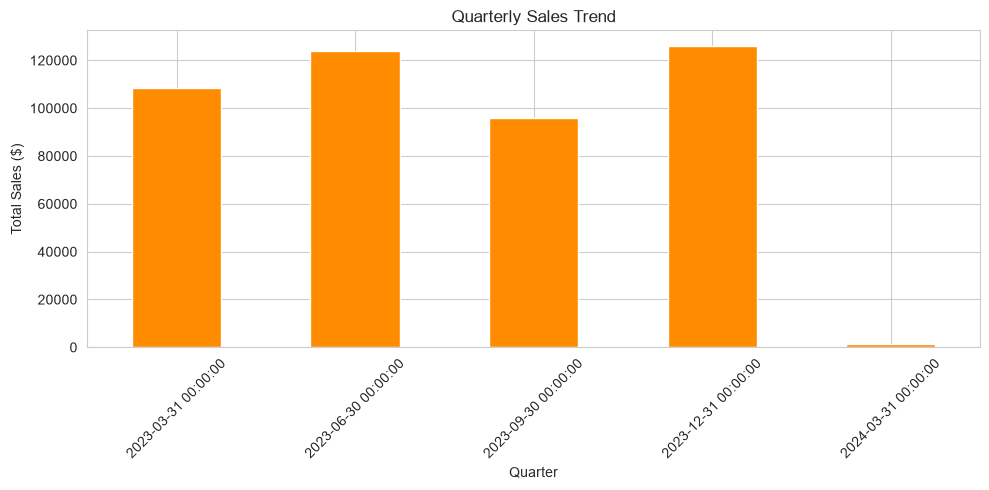

Date
2023-03-31    108500
2023-06-30    123735
2023-09-30     96045
2023-12-31    126190
2024-03-31      1530
Freq: QE-DEC, Name: Total Amount, dtype: int64


In [11]:
quarterly_sales = df.set_index('Date').resample('QE')['Total Amount'].sum()

plt.figure(figsize=(10, 5))
quarterly_sales.plot(kind='bar', color='darkorange')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(quarterly_sales)

**Observation:** Compare quarters to see if sales are growing, shrinking, or holding steady across the year. A strong Q4 could support the case for increased holiday inventory.

## 7. Customer Demographics — Age Distribution

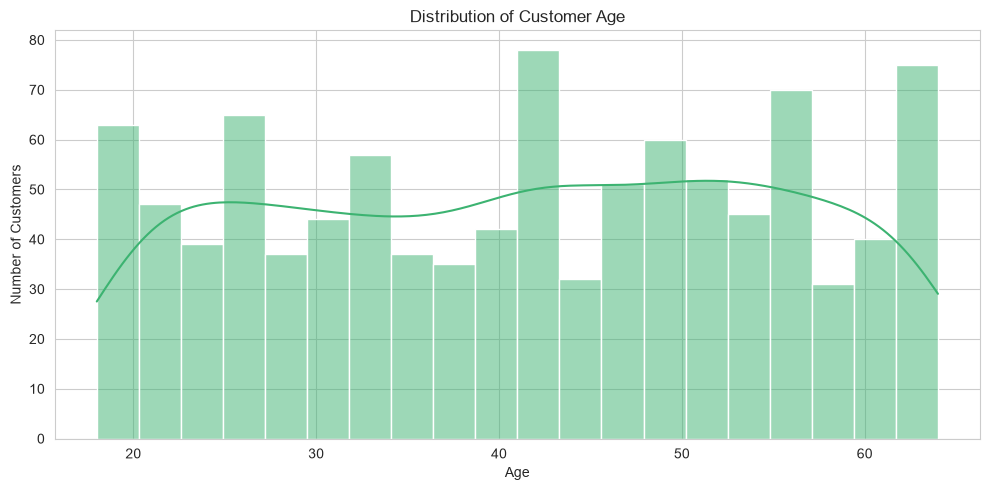

Average customer age: 41.4
Age range: 18 - 64


In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'], bins=20, kde=True, color='mediumseagreen')
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

print("Average customer age:", round(df['Age'].mean(), 1))
print("Age range:", df['Age'].min(), "-", df['Age'].max())

**Observation:** Identify which age bracket makes up the largest share of customers — this tells you who your core audience is and who marketing campaigns should target.

## 8. Customer Demographics — Gender Breakdown

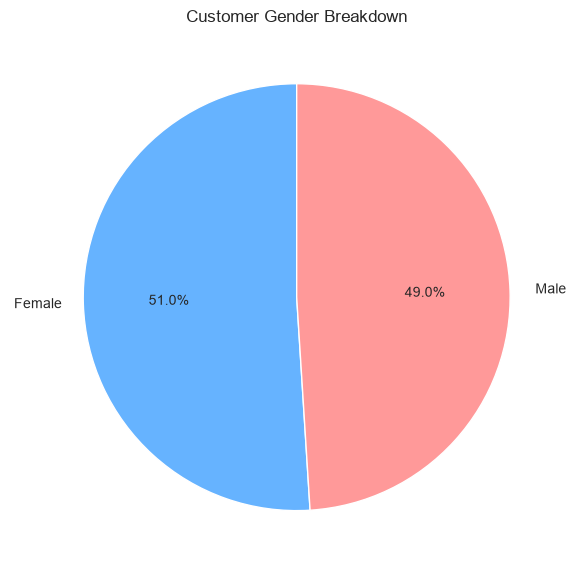

Gender
Female    510
Male      490
Name: count, dtype: int64


In [13]:
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
        colors=['#66b3ff', '#ff9999'], startangle=90)
plt.title('Customer Gender Breakdown')
plt.tight_layout()
plt.show()

print(gender_counts)

**Observation:** Note whether the customer base skews toward one gender, and cross-reference this later with spending patterns to see if there's a meaningful difference in average purchase value.

## 9. Product Analysis — Revenue by Category

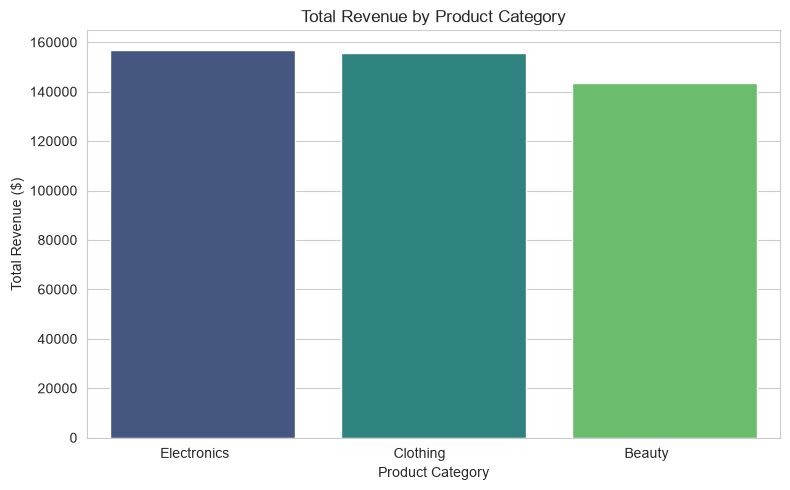

Product Category
Electronics         156905
Clothing            155580
Beauty              143515
Name: Total Amount, dtype: int64


In [14]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_revenue.index, y=category_revenue.values, hue=category_revenue.index,
            palette='viridis', legend=False)
plt.title('Total Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

print(category_revenue)

**Note:** This dataset records sales at the *category* level (Beauty, Clothing, Electronics) rather than individual product names, so a "top 10 best-selling products" breakdown isn't possible here — this chart substitutes a category-level revenue ranking, which serves the same purpose of identifying what sells best.

**Observation:** Identify the top-performing category by revenue — this is likely where inventory and marketing investment should be concentrated.

## 10. Product Analysis — Quantity Sold by Category

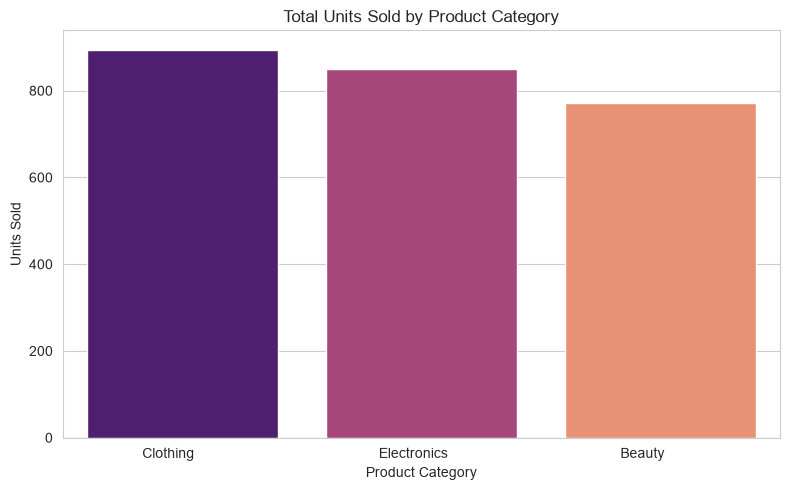

Product Category
Clothing            894
Electronics         849
Beauty              771
Name: Quantity, dtype: int64


In [15]:
category_quantity = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_quantity.index, y=category_quantity.values, hue=category_quantity.index,
            palette='magma', legend=False)
plt.title('Total Units Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.show()

print(category_quantity)

**Observation:** Compare this to the revenue-by-category chart above. A category with high unit sales but lower revenue suggests low price-per-item, while the reverse suggests fewer, higher-value transactions.

## 11. Correlation Heatmap

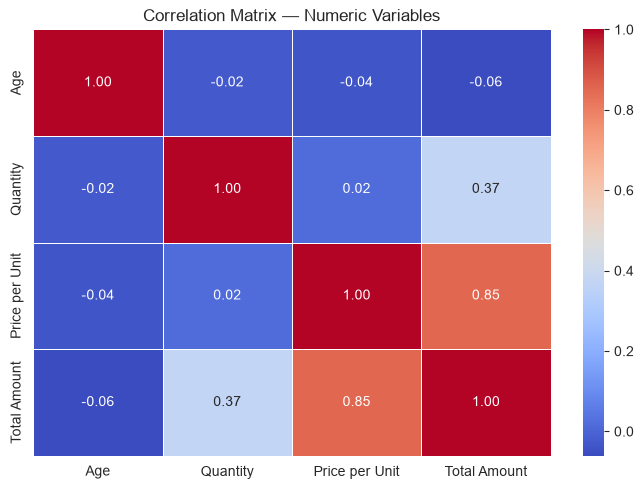

In [16]:
plt.figure(figsize=(7, 5))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix — Numeric Variables')
plt.tight_layout()
plt.show()

**Observation:** `Quantity` and `Price per Unit` both feed directly into `Total Amount` by definition, so expect strong correlation there. The more interesting question is whether `Age` correlates with spending at all — a weak correlation would suggest age isn't a strong driver of purchase size in this dataset.

## 12. Additional Insight — Average Spend by Gender and Category

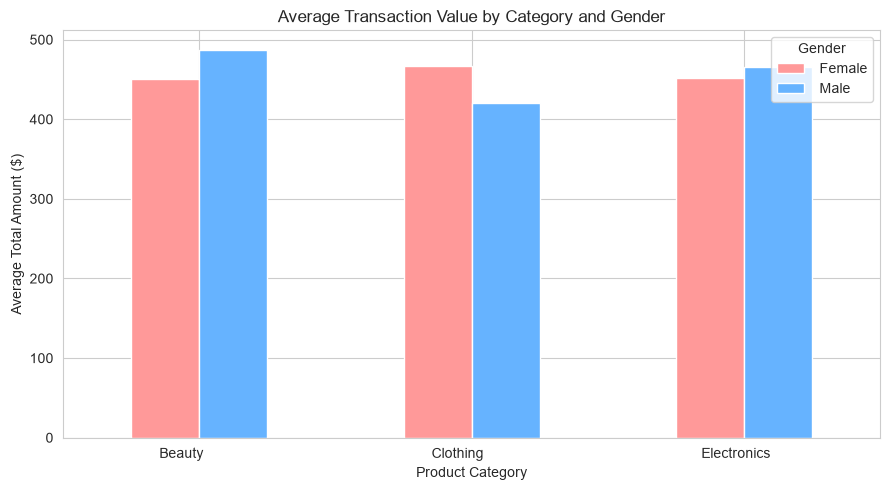

Gender                Female      Male  
Product Category                        
Beauty            450.783133  487.127660
Clothing          467.097701  419.802260
Electronics       451.382353  466.104651


In [17]:
avg_spend = df.groupby(['Product Category', 'Gender'])['Total Amount'].mean().unstack()

avg_spend.plot(kind='bar', figsize=(9, 5), color=['#ff9999', '#66b3ff'])
plt.title('Average Transaction Value by Category and Gender')
plt.xlabel('Product Category')
plt.ylabel('Average Total Amount ($)')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

print(avg_spend)

**Observation (non-obvious insight):** This breaks down average spend by both category and gender simultaneously, revealing whether certain categories drive higher-value transactions for one gender over another — a pattern that isn't visible from either single breakdown alone. This kind of insight is directly useful for targeted marketing campaigns.

## 13. Bonus — Sales by Day of the Week

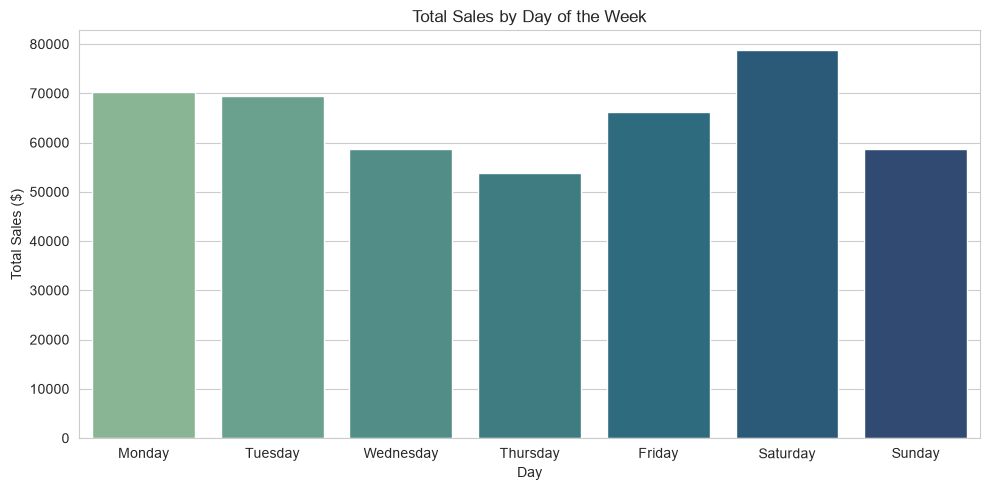

Day of Week
Monday       70250
Tuesday      69440
Wednesday    58770
Thursday     53835
Friday       66290
Saturday     78815
Sunday       58600
Name: Total Amount, dtype: int64


In [18]:
df['Day of Week'] = df['Date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sales_by_day = df.groupby('Day of Week')['Total Amount'].sum().reindex(day_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=sales_by_day.index, y=sales_by_day.values, hue=sales_by_day.index,
            palette='crest', legend=False)
plt.title('Total Sales by Day of the Week')
plt.xlabel('Day')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

print(sales_by_day)

**Observation:** If sales cluster around specific days (e.g. weekends), that's useful for timing promotions or staffing decisions.

## 14. Conclusion & Business Recommendations

Based on the analysis above, here are three actionable recommendations. **Fill in the bracketed values using the specific numbers your charts produced** before submitting:

1. **Inventory & marketing focus:** The `[category name]` category generates the highest revenue (`$[amount]`), so prioritize stock levels and marketing spend on this category, particularly heading into `[peak month/quarter]` when overall sales are highest.

2. **Targeted campaigns by demographic:** The `[age bracket]` age group represents the largest share of customers, and `[gender]` customers show higher average spend in the `[category]` category specifically. Marketing campaigns for this category should be tailored toward this demographic combination rather than a generic audience-wide message.

3. **Timing of promotions:** Sales are highest on `[day(s) of week]` and in `[quarter]`, suggesting promotional pushes and staffing should be concentrated around these periods rather than spread evenly across the year.

**Next steps:** A follow-up analysis with individual product-level data (rather than category-level) would allow more granular recommendations, such as identifying specific best-selling SKUs within each category.
